## Importing

# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Student Performance Dataset](https://www.kaggle.com/datasets/borovai0/student-performance-analytics-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('student_performance_data.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


## last Five row

In [4]:
df.tail()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
9995,109995,Female,6.86,59.65,60.41,39.51,66.43,44.97,Yes,Yes,High School,8.56,55.6720,C
9996,109996,Male,2.60,83.62,62.45,48.96,81.40,45.11,Yes,Yes,Bachelor,4.21,66.0930,C
9997,109997,Female,1.46,95.40,67.08,51.51,87.58,65.49,Yes,No,Bachelor,4.72,73.0355,B
9998,109998,Female,7.15,78.24,97.73,46.51,75.49,61.21,No,No,Bachelor,5.28,71.5400,B
9999,109999,Male,3.26,97.11,93.33,88.99,85.32,36.14,No,No,Bachelor,8.64,84.1005,B


## Shape of our dataset

In [5]:
df.shape

(10000, 14)

## List out all columns

In [6]:
df.columns

Index(['student_id', 'gender', 'study_hours_per_day', 'attendance_percentage',
       'assignment_score', 'midterm_score', 'final_exam_score',
       'participation_score', 'internet_access', 'extra_classes',
       'parent_education', 'sleep_hours', 'overall_score', 'grade'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

student_id                 int64
gender                    object
study_hours_per_day      float64
attendance_percentage    float64
assignment_score         float64
midterm_score            float64
final_exam_score         float64
participation_score      float64
internet_access           object
extra_classes             object
parent_education          object
sleep_hours              float64
overall_score            float64
grade                     object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  object 
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  object 
 9   extra_classes          10000 non-null  object 
 10  parent_education       10000 non-null  object 
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  object 
dtypes: float64(8), int64(1), object(5)
memory usage: 1.1+ M

## Check Null Value

In [9]:
df.isnull().sum()

student_id               0
gender                   0
study_hours_per_day      0
attendance_percentage    0
assignment_score         0
midterm_score            0
final_exam_score         0
participation_score      0
internet_access          0
extra_classes            0
parent_education         0
sleep_hours              0
overall_score            0
grade                    0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,student_id,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104999.50000,5.467825,70.493817,64.717809,62.322568,64.979987,55.103202,6.505165,63.826901
std,2886.89568,2.594134,17.295607,20.052779,21.710555,20.216141,25.955949,1.458246,10.230977
min,100000.00000,1.000000,40.000000,30.000000,25.000000,30.010000,10.000000,4.000000,33.263500
25%,102499.75000,3.220000,55.640000,47.320000,43.515000,47.400000,32.955000,5.220000,56.528125
50%,104999.50000,5.420000,70.780000,64.770000,62.050000,65.210000,55.055000,6.520000,63.780750
75%,107499.25000,7.740000,85.200000,81.760000,81.227500,82.500000,77.760000,7.792500,71.163125
max,109999.00000,10.000000,100.000000,99.990000,100.000000,100.000000,99.990000,9.000000,96.879500


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

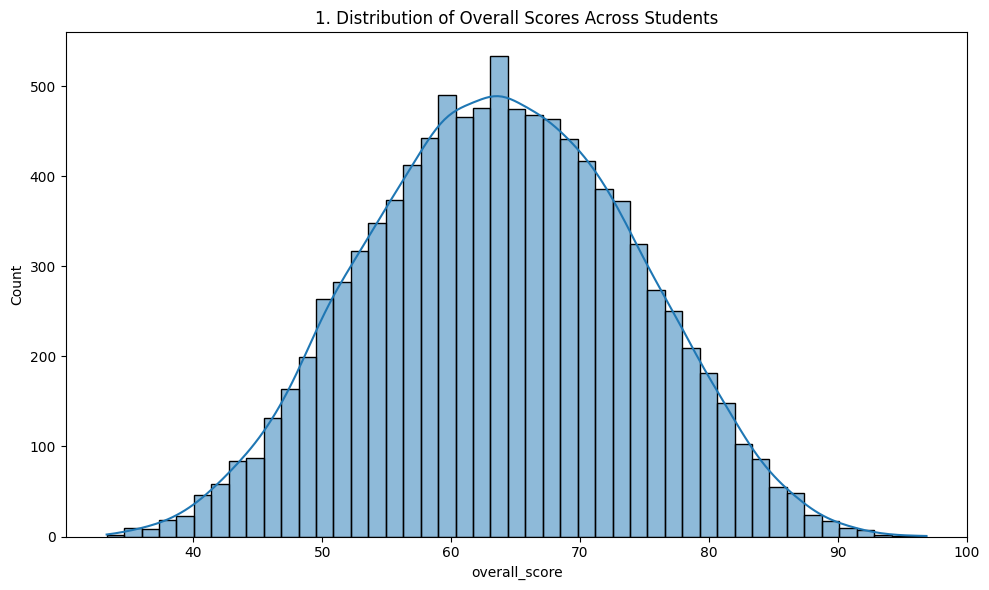

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['overall_score'], kde=True)
plt.title(f'{plot_no}. Distribution of Overall Scores Across Students')
show_fig()
plot_no += 1

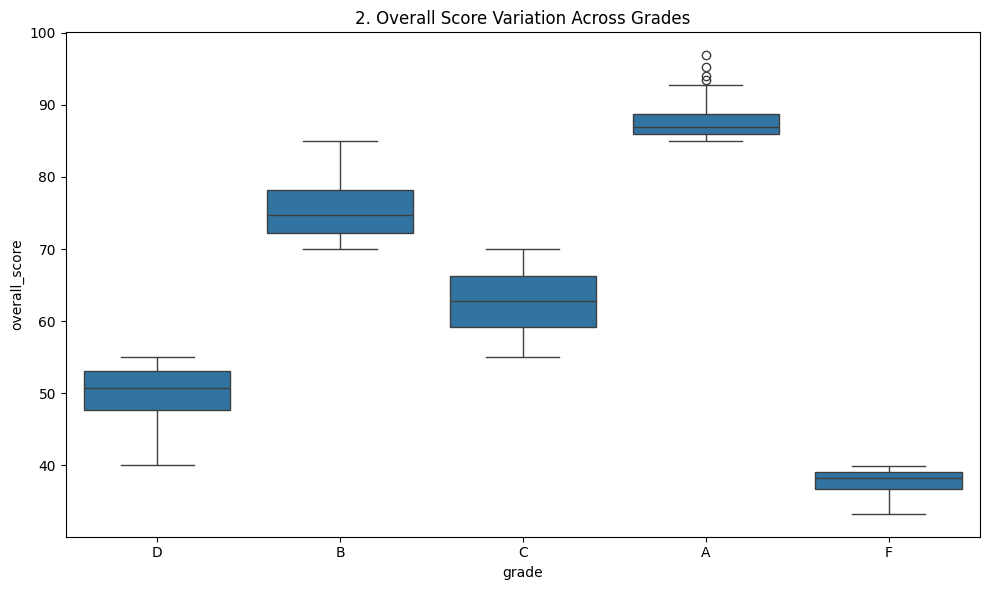

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='grade', y='overall_score', data=df)
plt.title(f'{plot_no}. Overall Score Variation Across Grades')
show_fig()
plot_no += 1

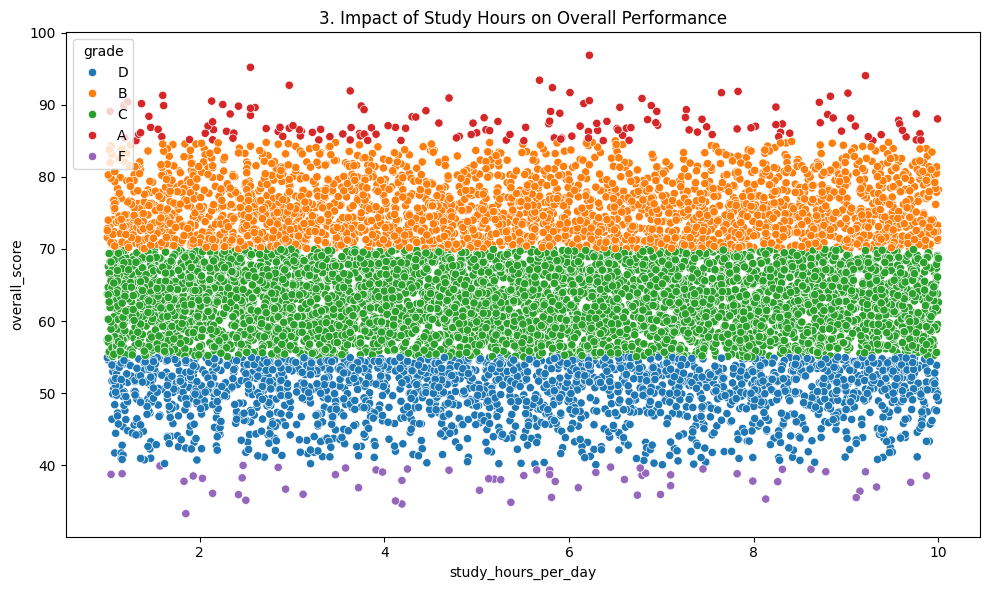

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='study_hours_per_day', y='overall_score', hue='grade', data=df)
plt.title(f'{plot_no}. Impact of Study Hours on Overall Performance')
show_fig()
plot_no += 1

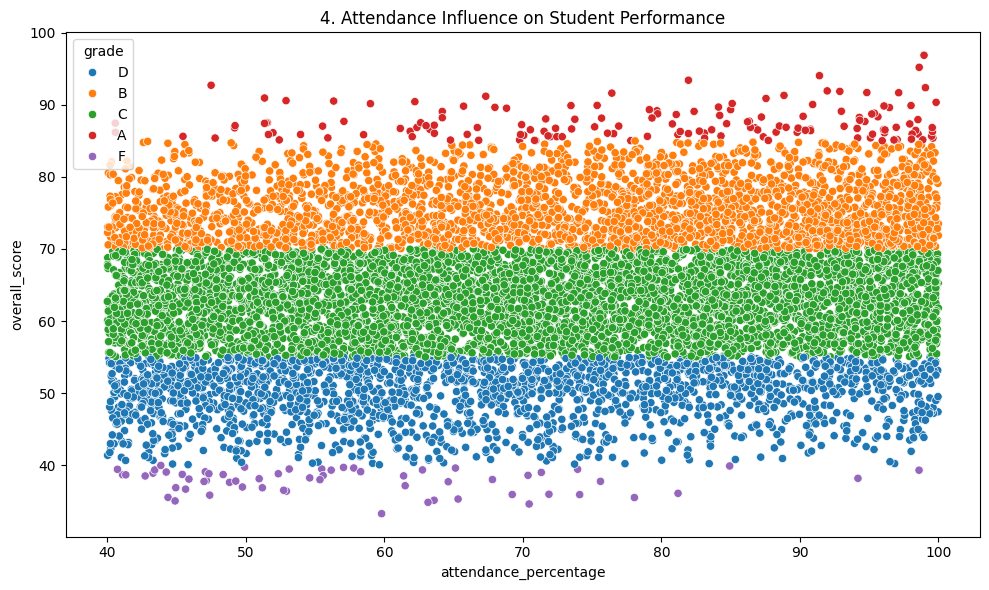

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='attendance_percentage', y='overall_score', hue='grade', data=df)
plt.title(f'{plot_no}. Attendance Influence on Student Performance')
show_fig()
plot_no += 1

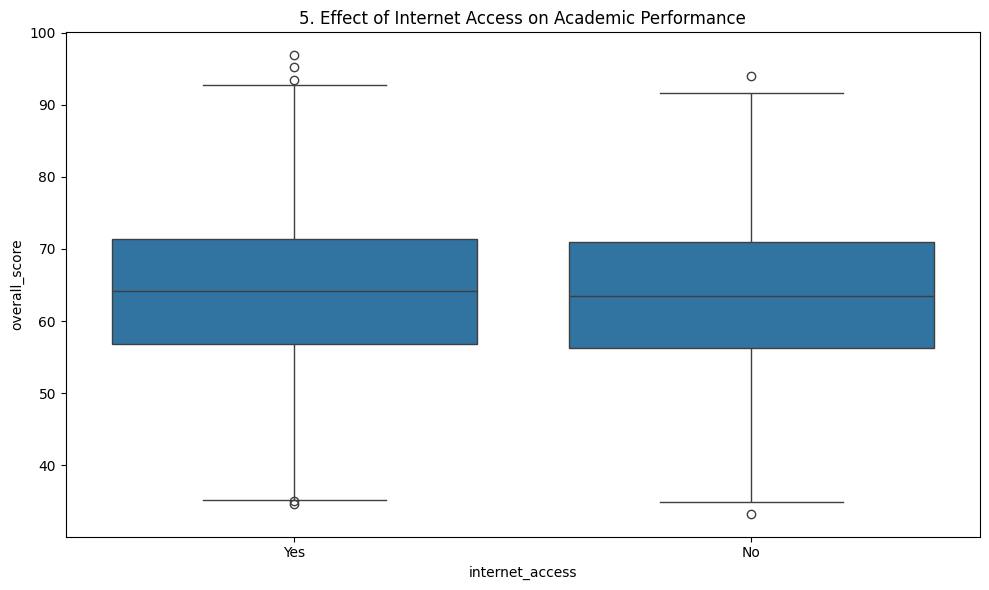

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='internet_access', y='overall_score', data=df)
plt.title(f'{plot_no}. Effect of Internet Access on Academic Performance')
show_fig()
plot_no += 1

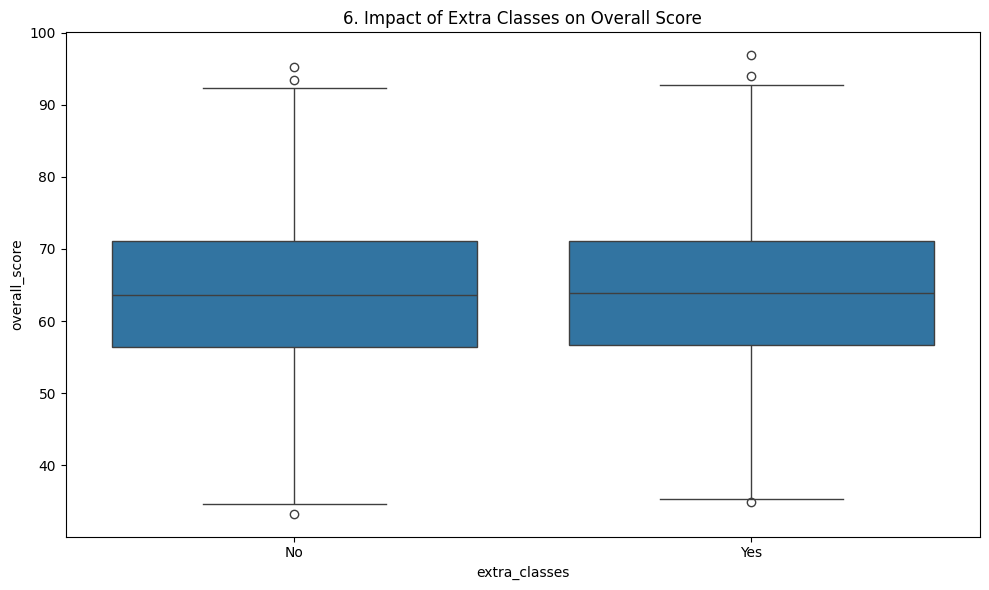

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='extra_classes', y='overall_score', data=df)
plt.title(f'{plot_no}. Impact of Extra Classes on Overall Score')
show_fig()
plot_no += 1

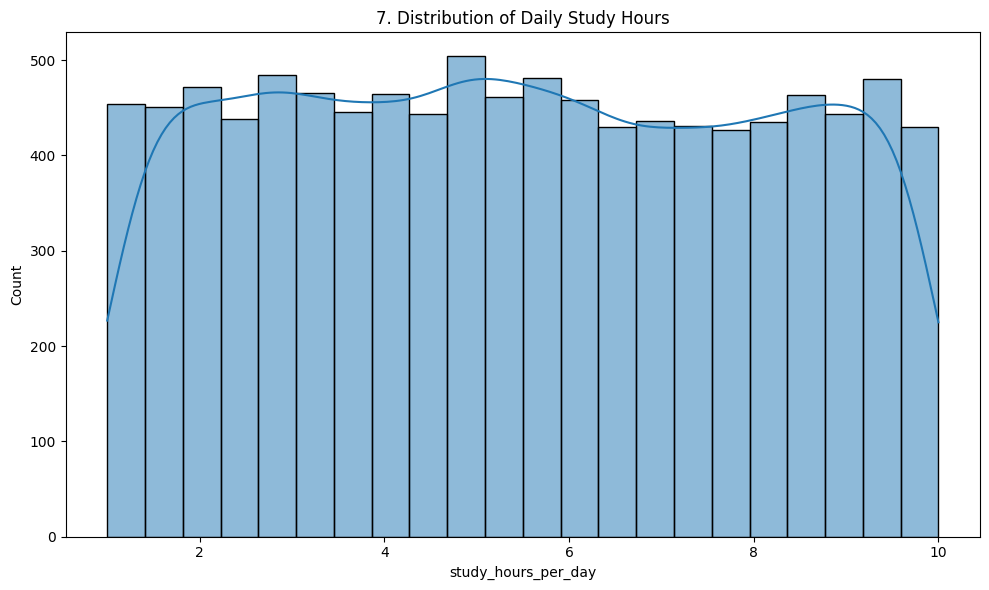

In [19]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['study_hours_per_day'], kde=True)
plt.title(f'{plot_no}. Distribution of Daily Study Hours')
show_fig()
plot_no += 1

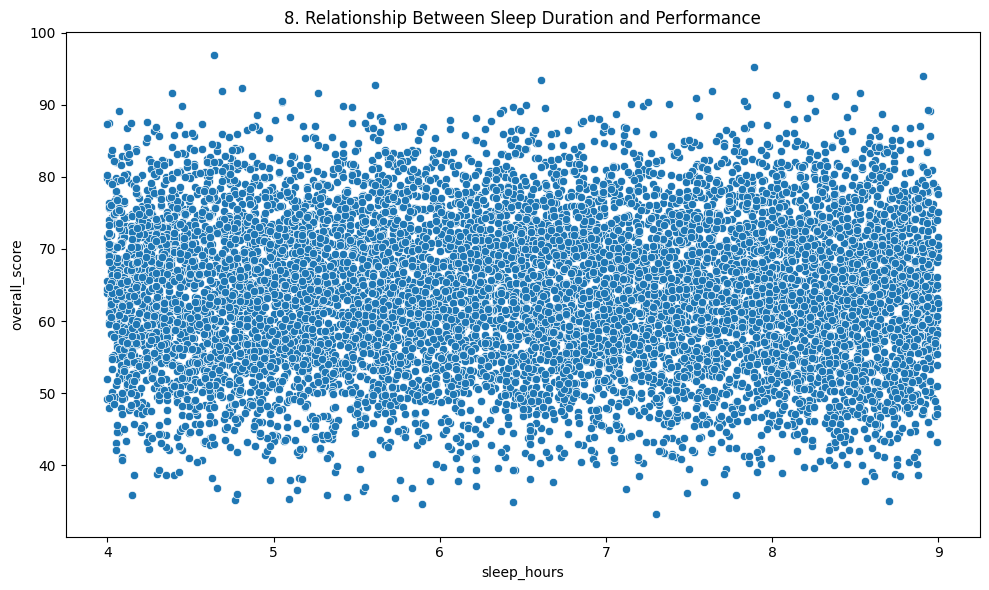

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='sleep_hours', y='overall_score', data=df)
plt.title(f'{plot_no}. Relationship Between Sleep Duration and Performance')
show_fig()
plot_no += 1

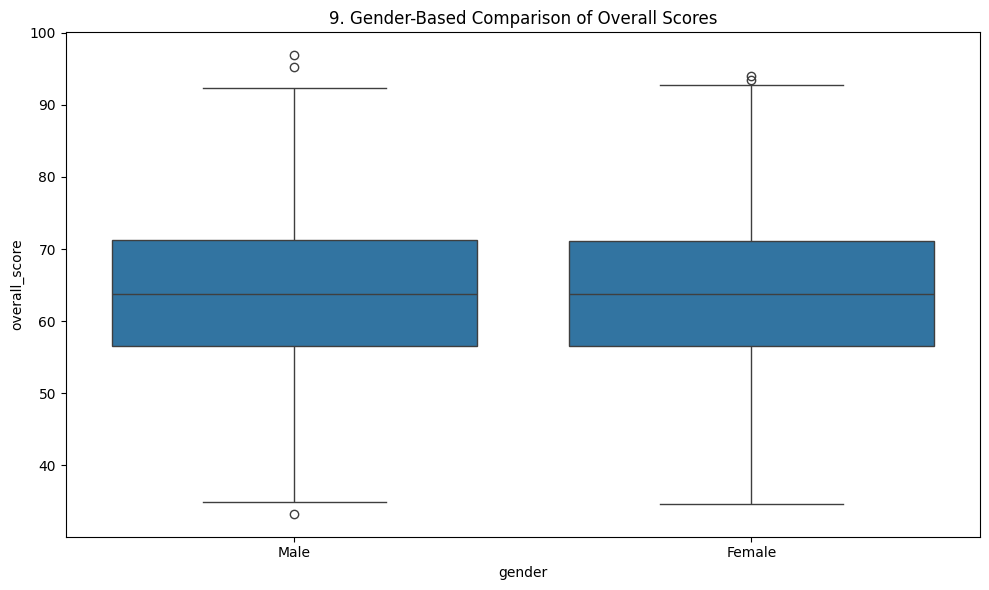

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='overall_score', data=df)
plt.title(f'{plot_no}. Gender-Based Comparison of Overall Scores')
show_fig()
plot_no += 1

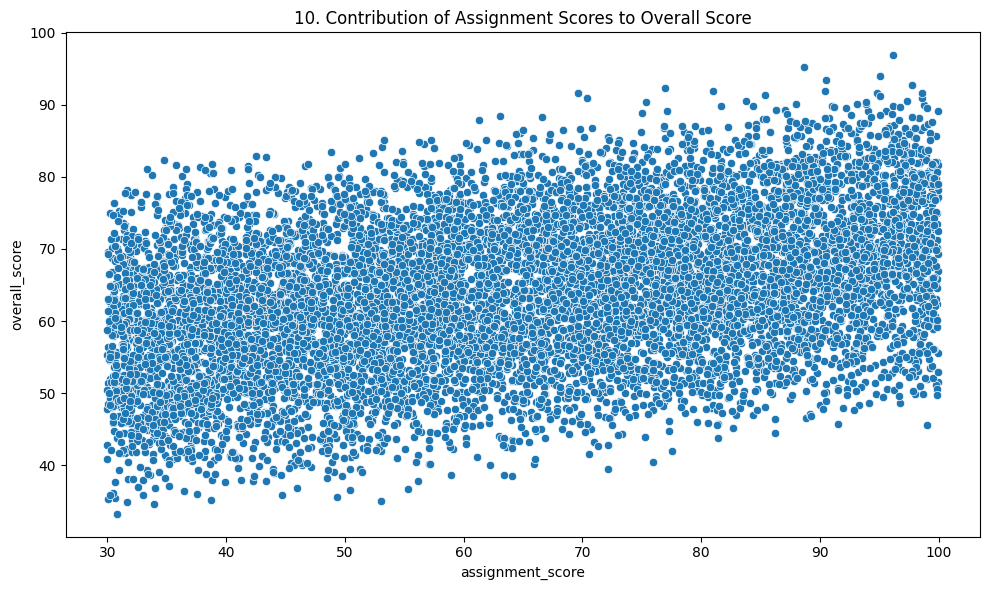

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='assignment_score', y='overall_score', data=df)
plt.title(f'{plot_no}. Contribution of Assignment Scores to Overall Score')
show_fig()
plot_no += 1

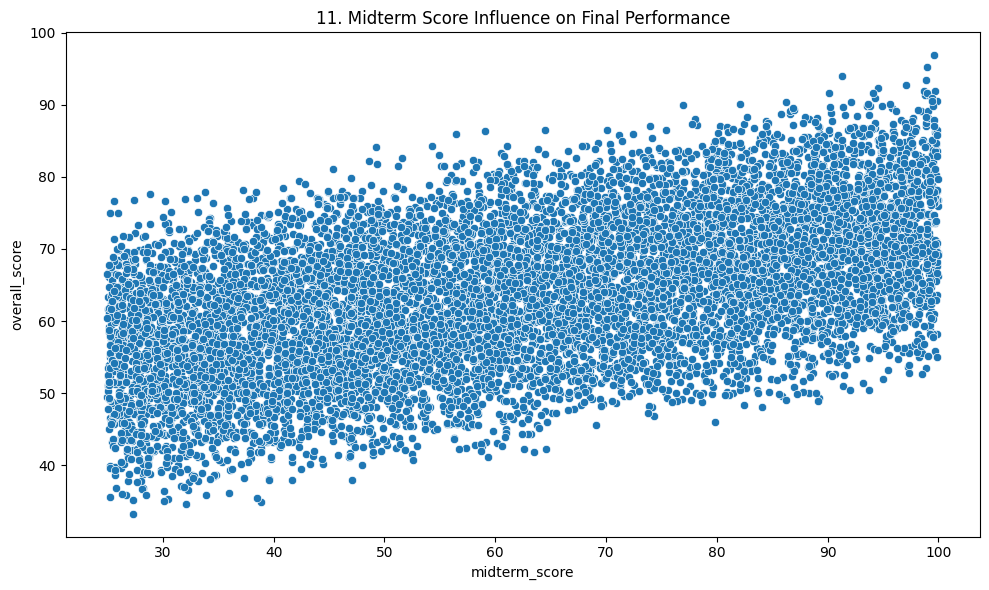

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='midterm_score', y='overall_score', data=df)
plt.title(f'{plot_no}. Midterm Score Influence on Final Performance')
show_fig()
plot_no += 1

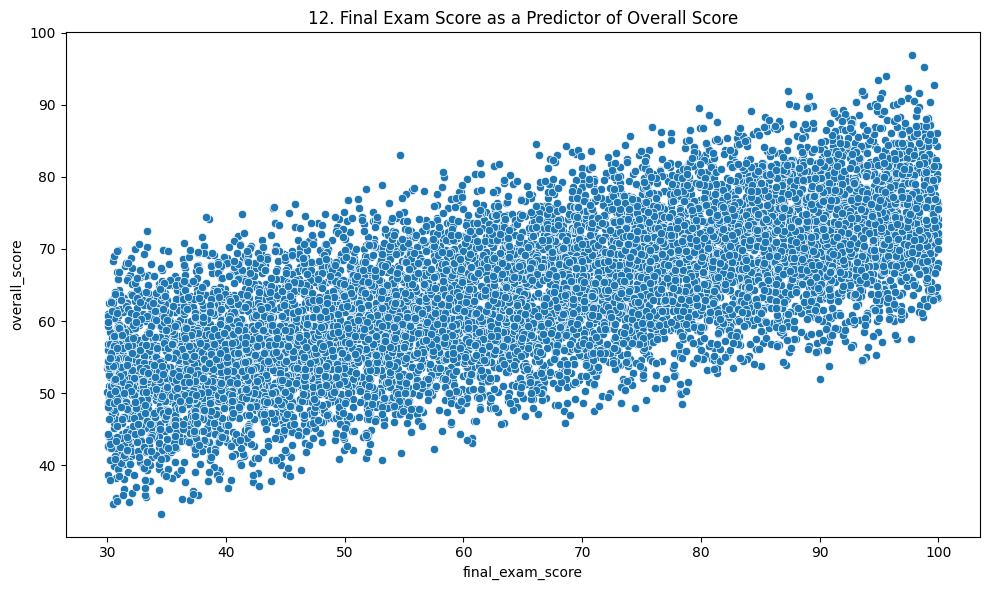

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='final_exam_score', y='overall_score', data=df)
plt.title(f'{plot_no}. Final Exam Score as a Predictor of Overall Score')
show_fig()
plot_no += 1

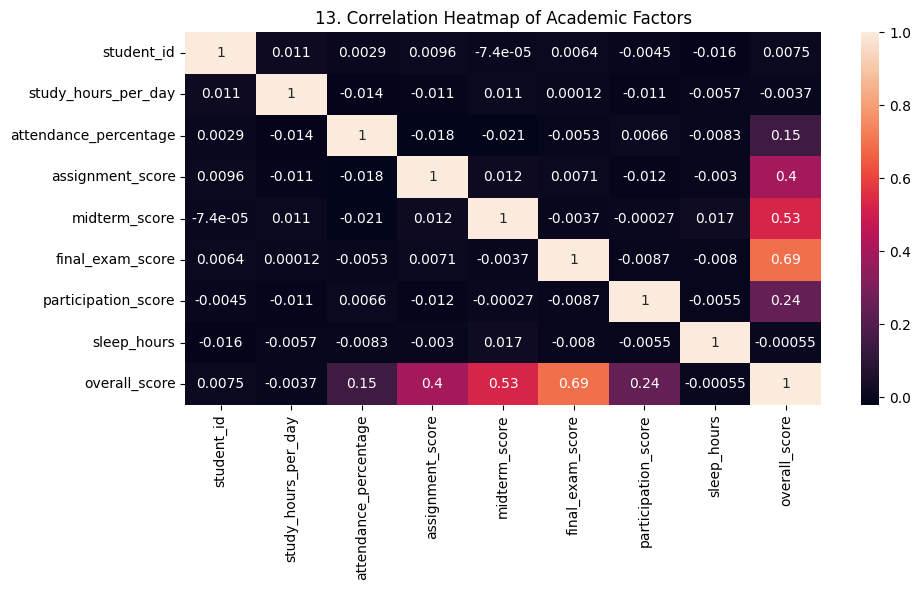

In [25]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Academic Factors')
show_fig()
plot_no += 1

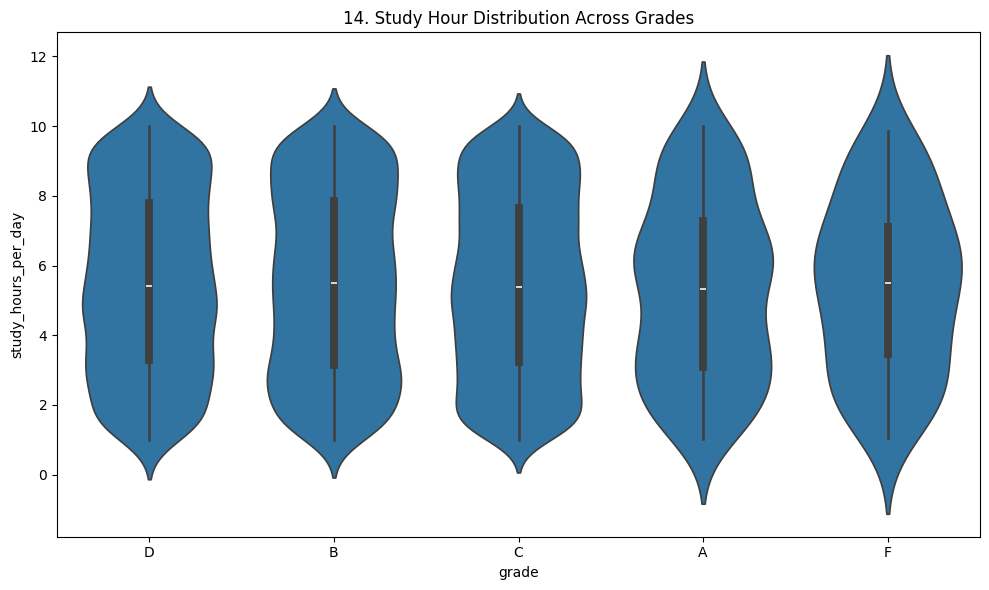

In [26]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='grade', y='study_hours_per_day', data=df)
plt.title(f'{plot_no}. Study Hour Distribution Across Grades')
show_fig()
plot_no += 1

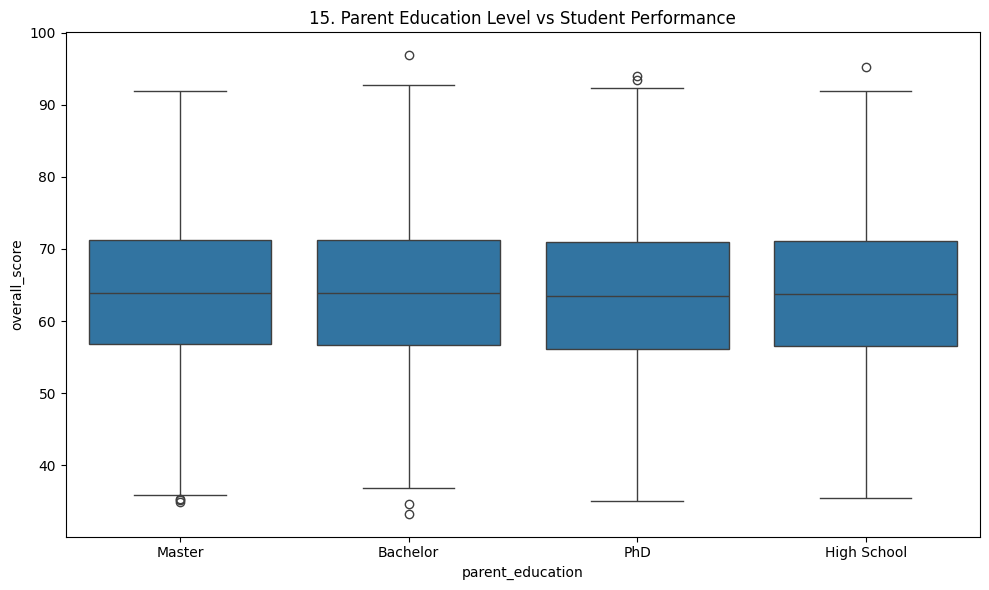

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='parent_education', y='overall_score', data=df)
plt.title(f'{plot_no}. Parent Education Level vs Student Performance')
show_fig()
plot_no += 1

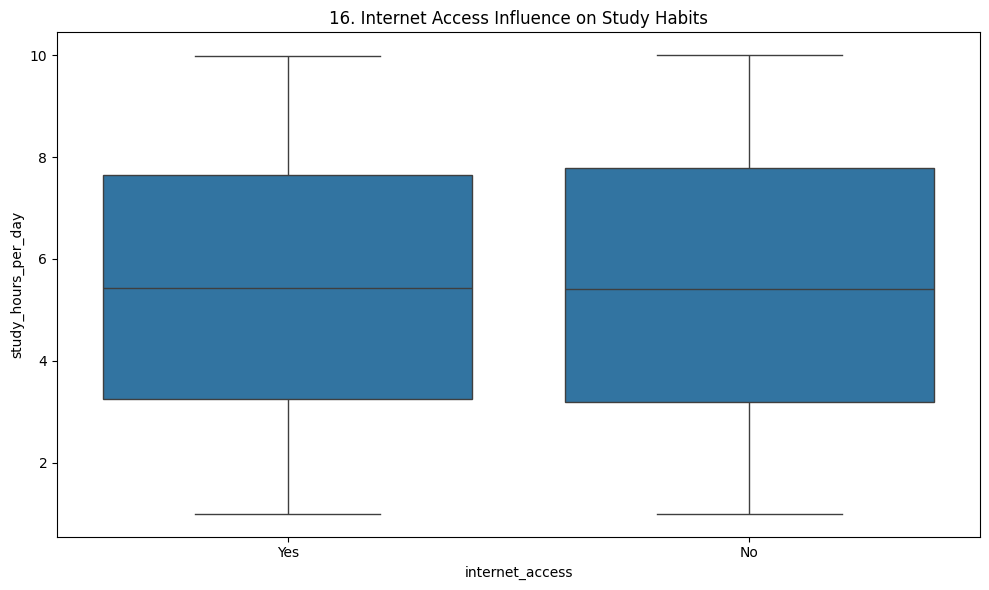

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='internet_access', y='study_hours_per_day', data=df)
plt.title(f'{plot_no}. Internet Access Influence on Study Habits')
show_fig()
plot_no += 1

# Model Training

## copy dataset

In [29]:
data = df.copy()

## encode categorical columns

In [30]:
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

## split features and target

In [31]:
X = data.drop('grade', axis=1)
y = data['grade']

## train test split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## apply feature scaling

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train model (Logistic Regression)

In [34]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## make predictions

In [35]:
y_pred = model.predict(X_test)

## calculate accuracy

In [36]:
acc = accuracy_score(y_test, y_pred)
print("Model Accuracy:", acc)

Model Accuracy: 0.987


## plot confusion matrix

<Figure size 800x600 with 0 Axes>

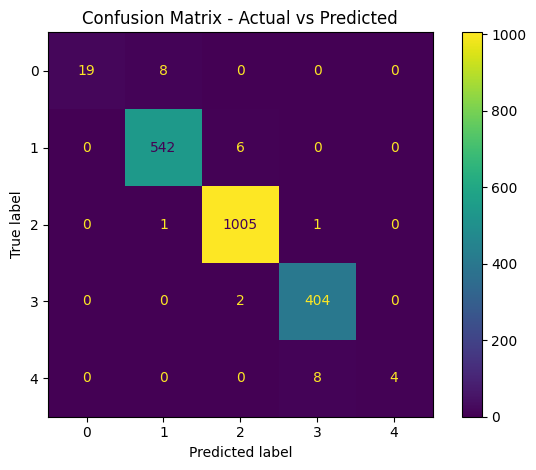

In [37]:
fig = plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Actual vs Predicted")
plt.tight_layout()
plt.show()